# Abgabe 3 – Image Stitching
**Computer Vision – Prof. Dr. Matthias O. Franz**

Panorama-Erstellung aus einer Serie von Fassadenaufnahmen mittels projektiver Entzerrung und verschiedener Blending-Strategien.

## Imports

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
import os

## Teilaufgabe a – Projektive Entzerrung mit beliebig vielen Passpunkten

Die Homographie-Berechnung nutzt die Pseudoinverse (via SVD), wodurch automatisch mehr als 4 Passpunkte unterstützt werden (least-squares Lösung).

In [2]:
def normalize_points(points):
    """Normalisiert Punkte für numerische Stabilität (isotrope Skalierung)."""
    points = np.array(points, dtype=float)
    centroid = np.mean(points, axis=0)
    points_centered = points - centroid
    scale = np.sqrt(2) / np.mean(np.linalg.norm(points_centered, axis=1))
    T = np.array([
        [scale, 0,    -scale * centroid[0]],
        [0,    scale, -scale * centroid[1]],
        [0,    0,      1]
    ])
    points_h = np.hstack([points, np.ones((len(points), 1))])
    points_norm = (T @ points_h.T).T
    return points_norm[:, :2], T


def calculate_projective_transformation(control_points, destination_points, normalize=True):
    """
    Berechnet die Homographie H so dass destination ~ H @ control.
    Unterstützt beliebig viele Passpunkte (>= 4) via Pseudoinverse (SVD).
    
    Args:
        control_points:     Liste von [x, y] Bildpunkten
        destination_points: Liste von [x, y] Weltpunkten
        normalize:          Ob Punkte vor Berechnung normalisiert werden sollen
    Returns:
        H: 3x3 Homographie-Matrix
    """
    control_points = np.array(control_points, dtype=float)
    destination_points = np.array(destination_points, dtype=float)

    if len(control_points) != len(destination_points):
        raise ValueError('Anzahl der Kontroll- und Zielpunkte muss übereinstimmen')
    if len(control_points) < 4:
        raise ValueError('Mindestens 4 Passpunkte erforderlich')

    if normalize:
        ctrl_norm, T1 = normalize_points(control_points)
        dest_norm, T2 = normalize_points(destination_points)
    else:
        ctrl_norm = control_points
        dest_norm = destination_points
        T1, T2 = None, None

    # Aufbau der Designmatrix A (2n x 9) für n Passpunkte
    rows = []
    for (xc, yc), (xd, yd) in zip(ctrl_norm, dest_norm):
        rows.append([xc, yc, 1,  0,  0,  0, -xd*xc, -xd*yc, -xd])
        rows.append([ 0,  0, 0, xc, yc,  1, -yd*xc, -yd*yc, -yd])

    A = np.array(rows)

    # Lösung via SVD: h ist der letzte rechte Singulärvektor
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)

    if normalize:
        H = np.linalg.inv(T2) @ H @ T1

    H = H / H[2, 2]
    return H


def projective_transform(image, H, output_shape):
    """
    Wendet Homographie H auf ein Bild an (inverse Abbildung).
    
    Returns:
        result: transformiertes Bild
        mask:   binäre Maske der gültigen Pixel
    """
    h_out, w_out = output_shape
    result = np.zeros((h_out, w_out, image.shape[2]), dtype=image.dtype)
    mask = np.zeros((h_out, w_out), dtype=np.float32)

    H_inv = np.linalg.inv(H)

    # Vektorisierte inverse Abbildung
    ys, xs = np.mgrid[0:h_out, 0:w_out]
    coords_h = np.stack([xs.ravel(), ys.ravel(), np.ones(h_out * w_out)])
    src_h = H_inv @ coords_h
    src_h /= src_h[2]
    x_src = src_h[0].reshape(h_out, w_out)
    y_src = src_h[1].reshape(h_out, w_out)

    x_int = np.round(x_src).astype(int)
    y_int = np.round(y_src).astype(int)

    valid = (x_int >= 0) & (x_int < image.shape[1]) & \
            (y_int >= 0) & (y_int < image.shape[0])

    result[valid] = image[y_int[valid], x_int[valid]]
    mask[valid] = 1.0

    return result, mask

In [3]:
# ── Test: Teilaufgabe a ─────────────────────────────────────────────────────
print("=" * 60)
print("TEST: normalize_points")
pts = np.array([[0.0, 0.0], [4.0, 0.0], [4.0, 3.0], [0.0, 3.0]])
pts_norm, T = normalize_points(pts)
centroid_after = np.mean(pts_norm, axis=0)
assert np.allclose(centroid_after, [0, 0], atol=1e-6), f"Centroid ≠ 0: {centroid_after}"
avg_dist = np.mean(np.linalg.norm(pts_norm, axis=1))
assert np.isclose(avg_dist, np.sqrt(2), atol=1e-6), f"Avg-Distanz ≠ √2: {avg_dist:.4f}"
print("  ✓ Centroid nach Normalisierung = (0,0)")
print(f"  ✓ Mittlere Distanz = √2 ≈ {avg_dist:.4f}")

print()
print("TEST: calculate_projective_transformation (Identität)")
# Wenn Bild- und Weltpunkte gleich sind → H ≈ Einheitsmatrix
src = [[0,0],[1,0],[1,1],[0,1]]
H = calculate_projective_transformation(src, src, normalize=False)
H_norm = H / H[2,2]
assert np.allclose(H_norm, np.eye(3), atol=1e-4), f"H ≠ I:\n{H_norm}"
print("  ✓ Identitäts-Passpunkte → H ≈ Einheitsmatrix")

print()
print("TEST: calculate_projective_transformation (bekannte Translation)")
# Translation um (+10, +5): dst = src + [10, 5]
src_pts = [[0,0],[100,0],[100,100],[0,100]]
dst_pts = [[10,5],[110,5],[110,105],[10,105]]
H = calculate_projective_transformation(src_pts, dst_pts, normalize=True)
# Teste einen Punkt: (0,0) → (10,5)
p_src = np.array([0, 0, 1.0])
p_dst = H @ p_src
p_dst /= p_dst[2]
assert np.allclose(p_dst[:2], [10, 5], atol=0.5), f"Punkt-Mapping falsch: {p_dst[:2]}"
print(f"  ✓ (0,0) → {p_dst[:2].round(2)} ≈ (10, 5)")

print()
print("TEST: projective_transform (Identitätshomographie)")
img_test = np.random.randint(0, 255, (20, 20, 3), dtype=np.uint8)
H_id = np.eye(3)
warped, mask = projective_transform(img_test, H_id, (20, 20))
assert warped.shape == (20, 20, 3), "Falsche Ausgabegröße"
assert np.all(mask == 1.0), "Maske nicht vollständig gesetzt"
assert np.array_equal(warped, img_test), "Identität verändert Bild"
print("  ✓ Identitäts-H → Bild unverändert, Maske vollständig")

print()
print("Alle Tests für Teilaufgabe a bestanden ✓")
print("=" * 60)

TEST: normalize_points
  ✓ Centroid nach Normalisierung = (0,0)
  ✓ Mittlere Distanz = √2 ≈ 1.4142

TEST: calculate_projective_transformation (Identität)
  ✓ Identitäts-Passpunkte → H ≈ Einheitsmatrix

TEST: calculate_projective_transformation (bekannte Translation)
  ✓ (0,0) → [10.  5.] ≈ (10, 5)

TEST: projective_transform (Identitätshomographie)
  ✓ Identitäts-H → Bild unverändert, Maske vollständig

Alle Tests für Teilaufgabe a bestanden ✓


## Teilaufgabe b – Passpunkte und Weltkoordinaten

Aufnahmen der HTWG-Fassade (Z-Gebäude) von 5 Standpunkten. Als Weltkoordinaten dienen Fensterrahmen-Rastereinheiten (1 Einheit ≈ 1 Fensterbreite ≈ 1,80 m).

Pro Bild wurden mindestens 4 Passpunkte gesetzt, je 2 davon im Überlappungsbereich mit dem Nachbarbild.

In [4]:
# -----------------------------------------------------------------------
# Passpunkte (Bildkoordinaten [x, y] in Pixel)
# Weltkoordinaten [x, y] in willkürlichen Einheiten (Fensterraster)
# Jede Spalte = 1800 Einheiten, jede Zeile = 1500 Einheiten
# -----------------------------------------------------------------------

# Bild 1 – linke Seite der Fassade
cps1 = [[276, 2139], [408, 1437], [1380, 1488], [1380, 2190]]
dps1 = [[0, 3000],   [0, 1500],   [1800, 1500], [1800, 3000]]

# Bild 2 – etwas weiter rechts
cps2 = [[294, 1944], [375, 1212], [1390, 1260], [1399, 1974]]
dps2 = [[1800, 3000], [1800, 1500], [3600, 1500], [3600, 3000]]

# Bild 3 – Mitte
cps3 = [[618, 1887], [684, 1149], [1950, 1203], [2004, 1902]]
dps3 = [[3600, 3000], [3600, 1500], [5400, 1500], [5400, 3000]]

# Bild 4 – rechts der Mitte
cps4 = [[1272, 1887], [1305, 1149], [2538, 1203], [2637, 1914]]
dps4 = [[5400, 3000], [5400, 1500], [7200, 1500], [7200, 3000]]

# Bild 5 – ganz rechts
cps5 = [[924, 1914],  [963, 1167],  [2265, 1209], [2298, 1950]]
dps5 = [[7200, 3000], [7200, 1500], [9000, 1500], [9000, 3000]]

CONTROL_POINTS_LIST     = [cps1, cps2, cps3, cps4, cps5]
DESTINATION_POINTS_LIST = [dps1, dps2, dps3, dps4, dps5]
FILENAMES               = ["b1.jpg", "b2.jpg", "b3.jpg", "b4.jpg", "b5.jpg"]

## Gewichtskarte

Gewicht w(i,j) = (1 - 2/M |i - M/2|) · (1 - 2/N |j - N/2|)  
→ Bildmitte = 1, Ränder = 0

In [5]:
def compute_weight_map(image_shape, mask):
    """
    Berechnet die Gewichtskarte nach der Formel aus dem Aufgabenblatt.
    w(i,j) = (1 - 2/M * |i - M/2|) * (1 - 2/N * |j - N/2|)
    Pixel außerhalb der Maske erhalten Gewicht 0.
    """
    h, w = image_shape
    # i = x-Achse (Spalten), j = y-Achse (Zeilen)
    i = np.arange(w)
    j = np.arange(h)
    wi = 1.0 - (2.0 / w) * np.abs(i - w / 2)
    wj = 1.0 - (2.0 / h) * np.abs(j - h / 2)
    weight_map = np.outer(wj, wi)  # shape (h, w)
    weight_map = np.clip(weight_map, 0, None)
    weight_map *= mask
    return weight_map

In [6]:
# ── Test: Gewichtskarte ──────────────────────────────────────────────────────
print("=" * 60)
print("TEST: compute_weight_map")
H, W = 100, 200
mask = np.ones((H, W), dtype=np.float32)
wmap = compute_weight_map((H, W), mask)

# Linker / oberer Rand (Index 0) ist exakt 0
assert wmap[0, 0]    == 0.0, f"Rand oben-links ≠ 0: {wmap[0,0]}"
assert wmap[0, W//2] == 0.0, f"Rand oben-mitte ≠ 0: {wmap[0, W//2]}"
assert wmap[H//2, 0] == 0.0, f"Rand links-mitte ≠ 0: {wmap[H//2, 0]}"
print("  ✓ Oberer/linker Bildrand (Index 0) hat Gewicht 0")

# Rechter / unterer Rand (letzter Index) ist sehr klein (≈ 1/N), aber nicht negativ
# Formel: w(N-1) = 1 - 2/N * |N-1 - N/2| = 1/N → nahe 0, aber diskret nicht exakt 0
assert wmap[-1, -1] >= 0.0,   "Negatives Gewicht am Rand"
assert wmap[-1, -1] < 1.0/min(H,W) * 2 + 1e-9, f"Rand unten-rechts unerwartet groß: {wmap[-1,-1]:.6f}"
print(f"  ✓ Unterer/rechter Rand nahe 0 (= 1/N = {1.0/H:.4f}), nicht negativ")

# Bildmitte = Maximum
cy, cx = H // 2, W // 2
center_val = wmap[cy, cx]
max_val = wmap.max()
assert np.isclose(center_val, max_val, atol=1e-4), f"Bildmitte ({center_val:.4f}) ≠ Maximum ({max_val:.4f})"
print(f"  ✓ Bildmitte hat Maximalgewicht = {center_val:.4f}")

# Alle Gewichte nicht-negativ
assert wmap.min() >= 0.0, "Negative Gewichte vorhanden"
print("  ✓ Alle Gewichte ≥ 0")

# Maske = 0 → Gewicht = 0
mask_partial = np.zeros((H, W), dtype=np.float32)
mask_partial[40:60, 80:120] = 1.0
wmap2 = compute_weight_map((H, W), mask_partial)
assert wmap2[0, 0] == 0.0,    "Maskierte Pixel haben Gewicht ≠ 0"
assert wmap2[50, 100] > 0.0,  "Nicht-maskierte Pixel haben Gewicht 0"
print("  ✓ Pixel außerhalb der Maske haben Gewicht 0")

print()
print("Alle Tests für Gewichtskarte bestanden ✓")
print("=" * 60)

TEST: compute_weight_map
  ✓ Oberer/linker Bildrand (Index 0) hat Gewicht 0
  ✓ Unterer/rechter Rand nahe 0 (= 1/N = 0.0100), nicht negativ
  ✓ Bildmitte hat Maximalgewicht = 1.0000
  ✓ Alle Gewichte ≥ 0
  ✓ Pixel außerhalb der Maske haben Gewicht 0

Alle Tests für Gewichtskarte bestanden ✓


## Teilaufgabe c – Einfaches Blending (Max-Gewicht / Gewichtetes Mittel)

In [7]:
def blend_images(img1, img2, weight1, weight2, method='max'):
    """
    Verschmilzt zwei gleichgroße Bilder.

    Args:
        img1, img2:       uint8 RGB-Bilder gleicher Größe
        weight1, weight2: float32 Gewichtskarten (0..1)
        method:           'max' – Pixel mit höherem Gewicht gewinnt
                          'avg' – gewichteter Durchschnitt
    Returns:
        Verschmolzenes uint8-Bild
    """
    img1 = img1.astype(np.float32)
    img2 = img2.astype(np.float32)

    mask1 = weight1 > 0
    mask2 = weight2 > 0
    overlap = mask1 & mask2

    panorama = np.zeros_like(img1)

    # Nicht-überlappende Bereiche direkt übernehmen
    panorama[mask1 & ~mask2] = img1[mask1 & ~mask2]
    panorama[mask2 & ~mask1] = img2[mask2 & ~mask1]

    if method == 'max':
        # Pixel mit höherem Gewicht übernehmen
        take1 = overlap & (weight1 >= weight2)
        take2 = overlap & (weight1 <  weight2)
        panorama[take1] = img1[take1]
        panorama[take2] = img2[take2]

    elif method == 'avg':
        # Gewichteter Durchschnitt im Überlappungsbereich
        w1 = weight1[overlap, None]
        w2 = weight2[overlap, None]
        total = w1 + w2
        total[total == 0] = 1e-10
        panorama[overlap] = (img1[overlap] * w1 + img2[overlap] * w2) / total

    return np.clip(panorama, 0, 255).astype(np.uint8)

In [8]:
# ── Test: Teilaufgabe c – blend_images ──────────────────────────────────────
print("=" * 60)
print("TEST: blend_images – method='max'")
# Linke Hälfte: Bild1 hat höheres Gewicht; rechte Hälfte: Bild2
img1 = np.full((4, 4, 3), 100, dtype=np.uint8)
img2 = np.full((4, 4, 3), 200, dtype=np.uint8)
w1 = np.array([[1,1,0,0],[1,1,0,0],[1,1,0,0],[1,1,0,0]], dtype=np.float32)
w2 = np.array([[0,0,1,1],[0,0,1,1],[0,0,1,1],[0,0,1,1]], dtype=np.float32)
result = blend_images(img1, img2, w1, w2, method='max')
assert np.all(result[:, :2] == 100), f"Linke Hälfte sollte 100 sein: {result[:,:2,0]}"
assert np.all(result[:, 2:] == 200), f"Rechte Hälfte sollte 200 sein: {result[:,2:,0]}"
print("  ✓ max-Blending: dominante Seite gewinnt korrekt")

print()
print("TEST: blend_images – method='avg' (Überlappungsbereich)")
img1 = np.full((2, 2, 3), 0,   dtype=np.uint8)
img2 = np.full((2, 2, 3), 100, dtype=np.uint8)
w1   = np.ones((2, 2), dtype=np.float32)   # Gewicht = 1
w2   = np.ones((2, 2), dtype=np.float32)   # Gewicht = 1  → Mittel = 50
result = blend_images(img1, img2, w1, w2, method='avg')
assert np.all(result == 50), f"avg-Blending: Erwarte 50, bekam {result[0,0]}"
print("  ✓ avg-Blending: gleiche Gewichte → Mittelwert korrekt (50)")

# Nicht-überlappend
print()
print("TEST: blend_images – nicht-überlappende Bereiche")
img1 = np.full((2, 4, 3), 80,  dtype=np.uint8)
img2 = np.full((2, 4, 3), 160, dtype=np.uint8)
w1 = np.array([[1,1,0,0],[1,1,0,0]], dtype=np.float32)
w2 = np.array([[0,0,1,1],[0,0,1,1]], dtype=np.float32)
result = blend_images(img1, img2, w1, w2, method='avg')
assert np.all(result[:, :2] == 80),  "Links: Erwarte 80"
assert np.all(result[:, 2:] == 160), "Rechts: Erwarte 160"
print("  ✓ Nicht-überlappende Bereiche direkt übernommen")

print()
print("Alle Tests für Teilaufgabe c bestanden ✓")
print("=" * 60)

TEST: blend_images – method='max'
  ✓ max-Blending: dominante Seite gewinnt korrekt

TEST: blend_images – method='avg' (Überlappungsbereich)
  ✓ avg-Blending: gleiche Gewichte → Mittelwert korrekt (50)

TEST: blend_images – nicht-überlappende Bereiche
  ✓ Nicht-überlappende Bereiche direkt übernommen

Alle Tests für Teilaufgabe c bestanden ✓


## Teilaufgabe d – Multi-Band Blending

- **Tiefpass** (Gauß-Blur): grobe Strukturen → gewichtetes Mittel
- **Hochpass** (Original − Tiefpass): feine Details → Pixel mit höherem Gewicht

In [9]:
def multi_band_blend(img1, img2, weight1, weight2, sigma=15):
    """
    Multi-band Blending:
    - Tiefpassanteil: gewichtetes Mittel
    - Hochpassanteil: Pixel mit höherem Gewicht

    Args:
        img1, img2:       uint8 RGB-Bilder
        weight1, weight2: float32 Gewichtskarten
        sigma:            Standardabweichung des Gauß-Filters
    Returns:
        Verschmolzenes uint8-Bild
    """
    f1 = img1.astype(np.float32)
    f2 = img2.astype(np.float32)

    # Tiefpass via Gauß-Filter
    lp1 = cv2.GaussianBlur(f1, (0, 0), sigma)
    lp2 = cv2.GaussianBlur(f2, (0, 0), sigma)

    # Hochpass = Original – Tiefpass
    hp1 = f1 - lp1
    hp2 = f2 - lp2

    # Tiefpassanteil: gewichtetes Mittel
    w1 = weight1[..., None]
    w2 = weight2[..., None]
    total = w1 + w2 + 1e-10
    blended_low = (lp1 * w1 + lp2 * w2) / total

    # Hochpassanteil: Pixel mit höherem Gewicht
    take1 = (weight1 >= weight2)[..., None]
    blended_high = np.where(take1, hp1, hp2)

    blended = blended_low + blended_high
    return np.clip(blended, 0, 255).astype(np.uint8)

In [10]:
# ── Test: Teilaufgabe d – multi_band_blend ───────────────────────────────────
print("=" * 60)
print("TEST: multi_band_blend – Ausgabeform und Wertebereich")
h, w = 50, 50
img1 = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
img2 = np.random.randint(0, 256, (h, w, 3), dtype=np.uint8)
w1   = np.ones((h, w),  dtype=np.float32) * 0.7
w2   = np.ones((h, w),  dtype=np.float32) * 0.3
result = multi_band_blend(img1, img2, w1, w2, sigma=5)
assert result.shape == (h, w, 3), f"Falsche Form: {result.shape}"
assert result.dtype == np.uint8,  f"Falscher Dtype: {result.dtype}"
assert result.min() >= 0 and result.max() <= 255, "Werte außerhalb [0, 255]"
print("  ✓ Ausgabeform korrekt:", result.shape)
print("  ✓ Dtype uint8, Wertebereich [0, 255]")

print()
print("TEST: multi_band_blend – wenn w1 >> w2 dominiert Bild 1 im Hochpass")
img1 = np.full((20, 20, 3), 200, dtype=np.uint8)
img2 = np.full((20, 20, 3),  50, dtype=np.uint8)
w1   = np.ones((20, 20), dtype=np.float32)
w2   = np.zeros((20, 20), dtype=np.float32)
result = multi_band_blend(img1, img2, w1, w2, sigma=3)
# w1 dominiert → Ergebnis nahe 200
mean_val = result.mean()
assert mean_val > 150, f"Erwartet nahe 200, bekam {mean_val:.1f}"
print(f"  ✓ Dominanz von Bild 1 (w1=1, w2=0): Mittelwert = {mean_val:.1f} ≈ 200")

print()
print("Alle Tests für Teilaufgabe d bestanden ✓")
print("=" * 60)

TEST: multi_band_blend – Ausgabeform und Wertebereich
  ✓ Ausgabeform korrekt: (50, 50, 3)
  ✓ Dtype uint8, Wertebereich [0, 255]

TEST: multi_band_blend – wenn w1 >> w2 dominiert Bild 1 im Hochpass
  ✓ Dominanz von Bild 1 (w1=1, w2=0): Mittelwert = 200.0 ≈ 200

Alle Tests für Teilaufgabe d bestanden ✓


## Panorama-Erstellung

In [11]:
def create_panorama(images, control_points_list, destination_points_list,
                    output_shape, blend_method='max', blending_type='simple'):
    """
    Erstellt ein Panorama aus mehreren Bildern.

    Args:
        images:                    Liste von RGB uint8 Bildern
        control_points_list:       Liste von Bildpasspunkten je Bild
        destination_points_list:   Liste von Weltpasspunkten je Bild
        output_shape:              (height, width) des Ausgabebildes
        blend_method:              'max' oder 'avg' (nur für blending_type='simple')
        blending_type:             'simple' oder 'multiband'
    Returns:
        Panorama als uint8 RGB-Bild
    """
    warped_images = []
    weight_maps   = []

    for idx, (img, cps, dps) in enumerate(zip(images, control_points_list, destination_points_list)):
        print(f"  Transformiere Bild {idx + 1}/{len(images)}...")
        H = calculate_projective_transformation(cps, dps)
        warped, mask = projective_transform(img, H, output_shape)
        warped_images.append(warped)
        weight_maps.append(compute_weight_map(output_shape, mask))

    print("  Blending...")
    panorama      = warped_images[0]
    total_weight  = weight_maps[0]

    for i in range(1, len(warped_images)):
        if blending_type == 'simple':
            panorama = blend_images(panorama, warped_images[i],
                                    total_weight, weight_maps[i],
                                    method=blend_method)
        elif blending_type == 'multiband':
            panorama = multi_band_blend(panorama, warped_images[i],
                                        total_weight, weight_maps[i])

        # Gesamtgewicht für nächste Iteration aktualisieren
        if blend_method == 'max':
            total_weight = np.maximum(total_weight, weight_maps[i])
        else:
            total_weight = total_weight + weight_maps[i]

    return panorama

## Ausführung – Alle 3 Varianten

5 Bilder geladen.
Ausgabegröße: 9100 x 1600 px

Einfaches Blending (Max-Gewicht)...
  Transformiere Bild 1/5...
  Transformiere Bild 2/5...
  Transformiere Bild 3/5...
  Transformiere Bild 4/5...
  Transformiere Bild 5/5...
  Blending...

Einfaches Blending (Gewichteter Durchschnitt)...
  Transformiere Bild 1/5...
  Transformiere Bild 2/5...
  Transformiere Bild 3/5...
  Transformiere Bild 4/5...
  Transformiere Bild 5/5...
  Blending...

Multi-Band Blending...
  Transformiere Bild 1/5...
  Transformiere Bild 2/5...
  Transformiere Bild 3/5...
  Transformiere Bild 4/5...
  Transformiere Bild 5/5...
  Blending...

Panoramen gespeichert.


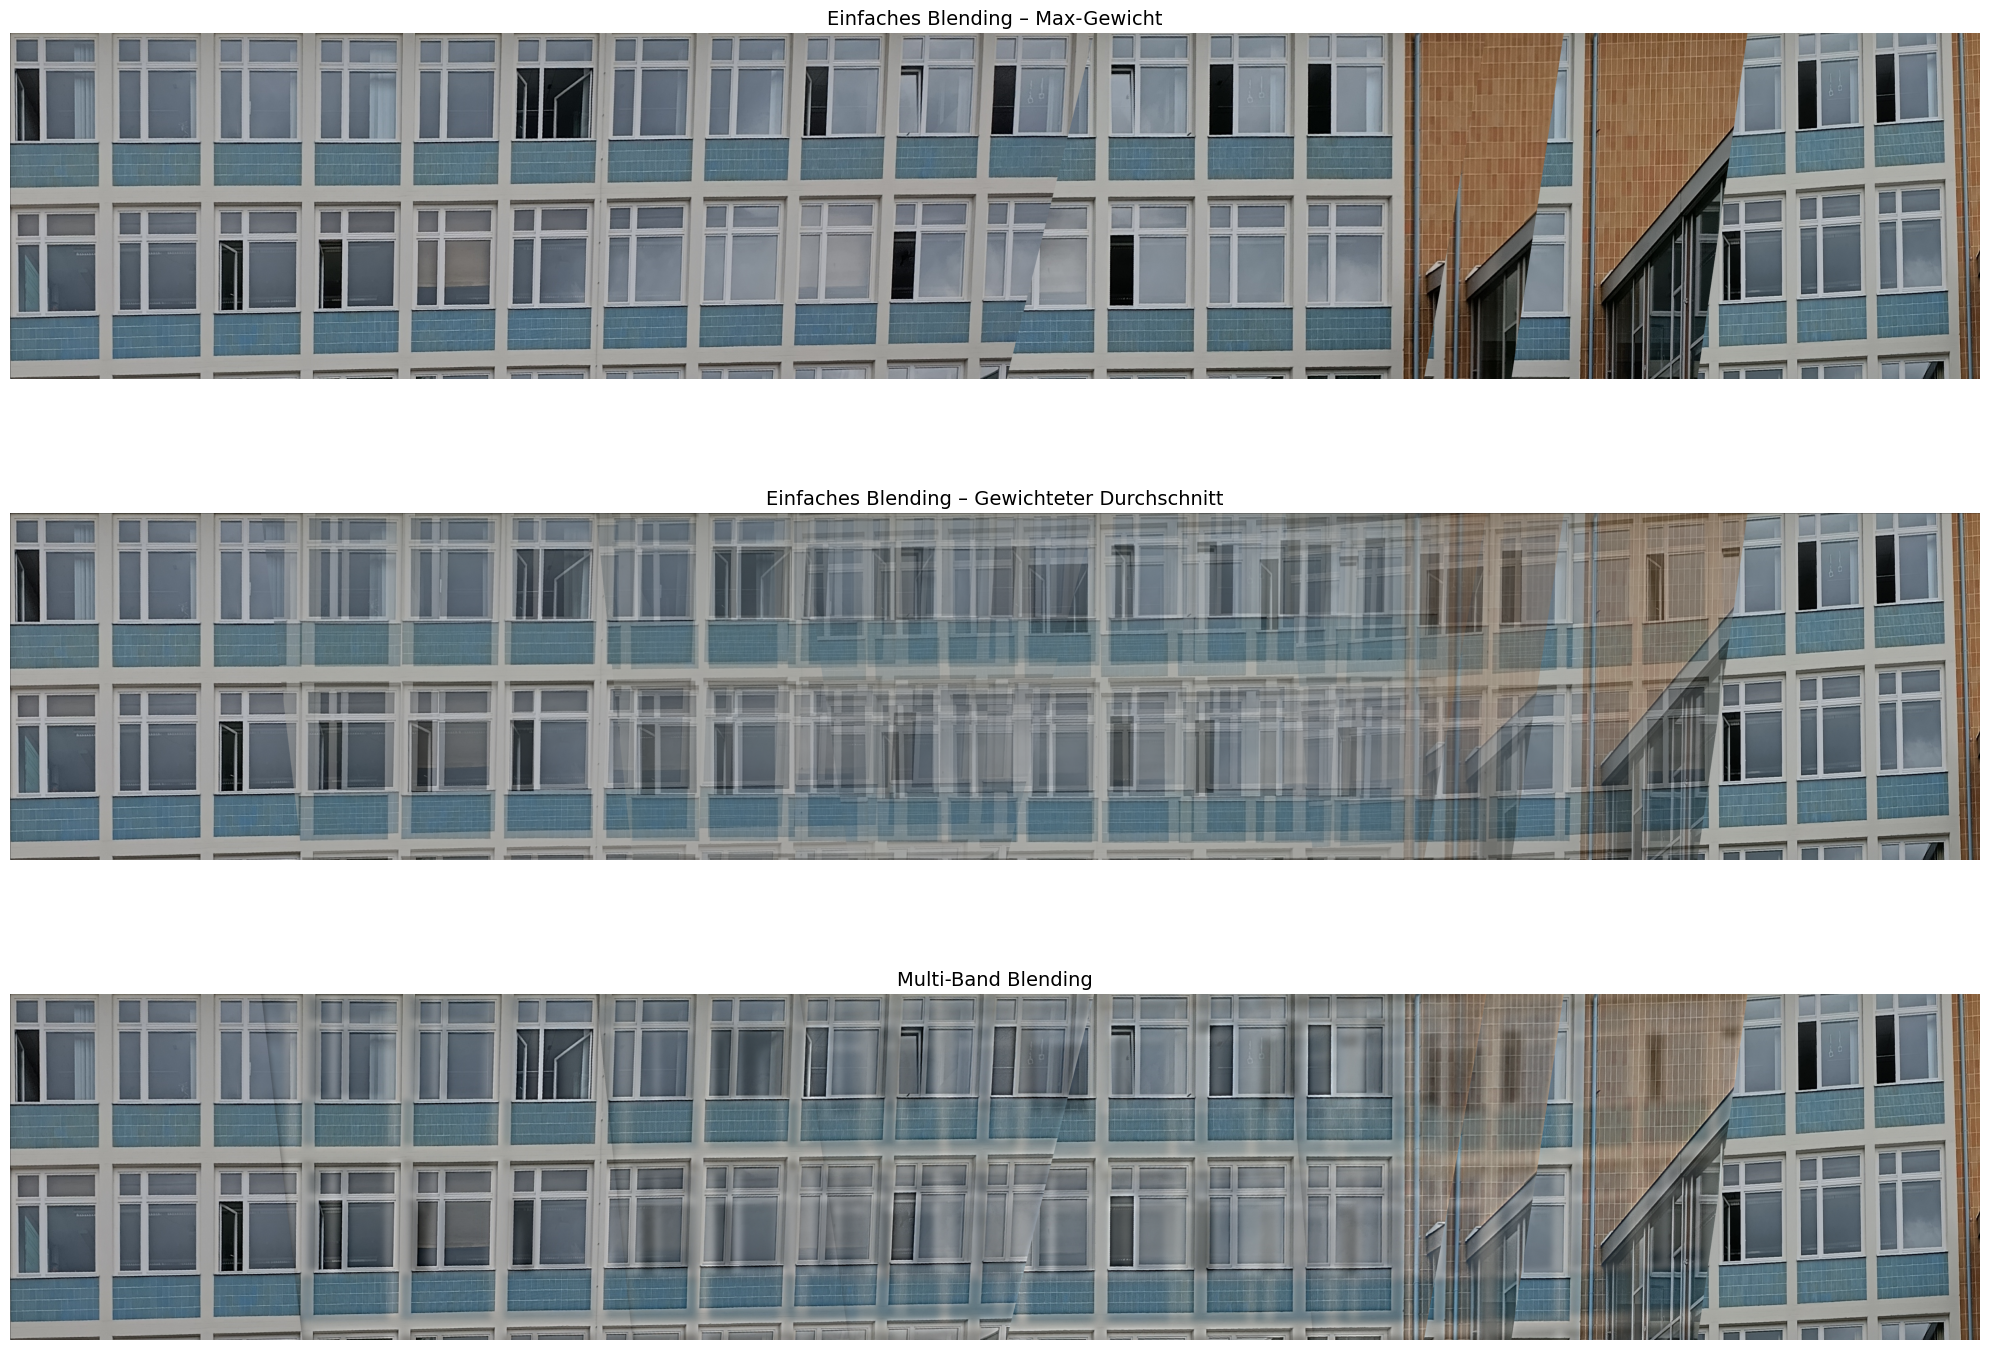

Fertig!


In [12]:
def perform_task(filenames=FILENAMES,
                 control_points_list=CONTROL_POINTS_LIST,
                 destination_points_list=DESTINATION_POINTS_LIST):
    """
    Führt die vollständige Panorama-Pipeline aus:
    1. Bilder laden
    2. Weltkoordinaten normalisieren
    3. Drei Panoramen erzeugen (simple-max, simple-avg, multiband)
    4. Ergebnisse speichern und anzeigen
    """
    # --- 1. Bilder laden ---
    images = []
    for fname in filenames:
        if not os.path.exists(fname):
            print(f"Fehler: Datei {fname} nicht gefunden!")
            return
        img = cv2.imread(fname)
        images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    print(f"{len(images)} Bilder geladen.")

    # --- 2. Weltkoordinaten normalisieren (Offset auf 0 setzen) ---
    all_world = np.vstack(destination_points_list)
    min_x, min_y = np.min(all_world, axis=0)
    max_x, max_y = np.max(all_world, axis=0)
    output_shape = (int(max_y - min_y) + 100, int(max_x - min_x) + 100)
    print(f"Ausgabegröße: {output_shape[1]} x {output_shape[0]} px")

    norm_dps = [[[x - min_x, y - min_y] for x, y in dps]
                for dps in destination_points_list]

    # --- 3. Panoramen erzeugen ---
    print("\nEinfaches Blending (Max-Gewicht)...")
    pan_max = create_panorama(images, control_points_list, norm_dps,
                              output_shape, blend_method='max', blending_type='simple')

    print("\nEinfaches Blending (Gewichteter Durchschnitt)...")
    pan_avg = create_panorama(images, control_points_list, norm_dps,
                              output_shape, blend_method='avg', blending_type='simple')

    print("\nMulti-Band Blending...")
    pan_multi = create_panorama(images, control_points_list, norm_dps,
                                output_shape, blend_method='avg', blending_type='multiband')

    # --- 4. Speichern ---
    cv2.imwrite("panorama_simple_max.jpg",  cv2.cvtColor(pan_max,   cv2.COLOR_RGB2BGR))
    cv2.imwrite("panorama_simple_avg.jpg",  cv2.cvtColor(pan_avg,   cv2.COLOR_RGB2BGR))
    cv2.imwrite("panorama_multiband.jpg",   cv2.cvtColor(pan_multi, cv2.COLOR_RGB2BGR))
    print("\nPanoramen gespeichert.")

    # --- 5. Anzeigen ---
    fig, axes = plt.subplots(3, 1, figsize=(20, 15))
    titles = [
        "Einfaches Blending – Max-Gewicht",
        "Einfaches Blending – Gewichteter Durchschnitt",
        "Multi-Band Blending"
    ]
    for ax, img, title in zip(axes, [pan_max, pan_avg, pan_multi], titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=14)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig("panorama_comparison.jpg", dpi=150, bbox_inches='tight')
    plt.show()
    print("Fertig!")


perform_task()